In [10]:
import pandas as pd
import sqlalchemy as sql


In [150]:
import urllib

# Conexão com o banco de dados

driver = "{ODBC Driver 17 for SQL Server}" 
server = "192.168.200.100"
database = "OLIST_PROJECT"
user = "dbolist"
password = "dbolist"


params = urllib.parse.quote_plus(
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={user};"
    f"PWD={password};"
    "TrustServerCertificate=yes;"
)

engine = sql.create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

In [12]:
# Teste de conexão com o banco
pd.read_sql('SELECT * FROM CLIENTES', engine)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP
...,...,...,...,...,...
99436,fffecc9f79fd8c764f843e9951b11341,e5794df8573fa179a90a7b797fc4b71f,95630,parobe,RS
99437,fffeda5b6d849fbd39689bb92087f431,afbb5a642107cf6bb1ca68e863175f03,22461,rio de janeiro,RJ
99438,ffff42319e9b2d713724ae527742af25,680213db6ebd9e4f24d03280cbe10346,6754,taboao da serra,SP
99439,ffffa3172527f765de70084a7e53aae8,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG


In [13]:
df_clientes = pd.read_csv('./datasets/olist_customers_dataset.csv')
print('Clientes lidos com sucesso!')

Clientes lidos com sucesso!


In [14]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [15]:
df_clientes['customer_zip_code_prefix'].isna().sum()

np.int64(0)

In [17]:
# Inserir os dados na tabela de clientes 

df_clientes.to_sql('CLIENTES', con=engine, if_exists='replace', index=False)

print('Clientes inseridos com sucesso!')

ProgrammingError: (pyodbc.ProgrammingError) ('42000', "[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Não foi possível descartar o objeto 'CLIENTES' porque há referência a ele em uma restrição FOREIGN KEY. (3726) (SQLExecDirectW)")
[SQL: 
DROP TABLE [CLIENTES]]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [18]:
# Verificação 
pd.read_sql('SELECT TOP 10 * FROM CLIENTES', engine)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP
5,0004164d20a9e969af783496f3408652,104bdb7e6a6cdceaa88c3ea5fa6b2b93,13272,valinhos,SP
6,000419c5494106c306a97b5635748086,14843983d4a159080f6afe4b7f346e7c,24220,niteroi,RJ
7,00046a560d407e99b969756e0b10f282,0b5295fc9819d831f68eb0e9a3e13ab7,20540,rio de janeiro,RJ
8,00050bf6e01e69d5c0fd612f1bcfb69c,e3cf594a99e810f58af53ed4820f25e5,98700,ijui,RS
9,000598caf2ef4117407665ac33275130,7e0516b486e92ed3f3afdd6d1276cfbd,35540,oliveira,MG


In [19]:
# Base de pedidos
df_pedidos = pd.read_csv('./datasets/olist_orders_dataset.csv')

In [20]:
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
df_pedidos.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [22]:
df_pedidos['order_approved_at'].isna().sum()

np.int64(160)

In [23]:
df_pedidos.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [24]:
# Transformar tipos em datetime 

colunas = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date' ]

for col in colunas:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])
    
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [25]:
df_pedidos.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [27]:
# Input de dados no SQL 

df_pedidos.to_sql('PEDIDOS', con=engine, if_exists='append', index=False)

print('Comando inserido com sucesso!')

Comando inserido com sucesso!


In [29]:
pd.read_sql('SELECT top 10 * FROM PEDIDOS', engine)

,id_pedido,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,151482,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,151483,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,151484,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,151485,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,151486,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,151487,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,151488,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,151489,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,151490,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,151491,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


In [30]:
df_pagamentos = pd.read_csv('./datasets/olist_order_payments_dataset.csv', dtype=str)

print('CSV Carregado com sucesso!')

CSV Carregado com sucesso!


In [31]:
df_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   order_id              103886 non-null  object
 1   payment_sequential    103886 non-null  object
 2   payment_type          103886 non-null  object
 3   payment_installments  103886 non-null  object
 4   payment_value         103886 non-null  object
dtypes: object(5)
memory usage: 4.0+ MB


In [ ]:
df_pagamentos.isna().sum()

# Não há valores nulos, então posso apenas tratar os dados estranhos e fazer o input no banco de dados. 

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [32]:
lista_de_id = pd.read_sql('SELECT order_id FROM PEDIDOS', engine)



In [33]:
## CÓDIGO FEITO POR I.A

# 1. Extraia APENAS os valores da coluna 'order_id' para um Set
# O .tolist() garante que você tenha uma lista de strings puras
set_ids_pedidos = set(lista_de_id['order_id'].astype(str).unique())

# 2. Verifique se agora o header sumiu da lista (deve imprimir um ID real)
print(f"Exemplo de ID real do banco: {list(set_ids_pedidos)[0]}")

# 3. Filtre o DataFrame de pagamentos
df_pagamentos = df_pagamentos[df_pagamentos['order_id'].isin(set_ids_pedidos)]

# 4. Verificação de Auditoria (Task 2.3)
print(f"Agora sim! Registros encontrados: {len(df_pagamentos)}")

Exemplo de ID real do banco: 03e327642028582cff3316f1726a9f00
Agora sim! Registros encontrados: 103886


In [ ]:
df_pagamentos.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [34]:
df_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   order_id              103886 non-null  object
 1   payment_sequential    103886 non-null  object
 2   payment_type          103886 non-null  object
 3   payment_installments  103886 non-null  object
 4   payment_value         103886 non-null  object
dtypes: object(5)
memory usage: 4.0+ MB


In [35]:
df_pagamentos['payment_sequential'] = pd.to_numeric(df_pagamentos['payment_sequential'])

In [36]:
df_pagamentos['payment_value'] = df_pagamentos['payment_value'].astype(float)

In [37]:
df_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  object 
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ MB


In [38]:
df_pagamentos.to_sql('PAGAMENTOS', con=engine, if_exists='append', index=False)

393

In [39]:
pd.read_sql('SELECT count(*) FROM pagamentos', engine)

,
0,103886


In [ ]:
# Importando a view criada para calculo de churn

view = pd.read_sql ('SELECT * FROM VW_CHURN_PAGAMENTOS', engine)

view.head(5)

,ID_PEDIDO,STATUS_PEDIDO,DATA_COMPRA,TIPO_PAGAMENTO,VALOR_PAGO,ESTADO,CIDADE
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,credit_card,72.19,RJ,campos dos goytacazes
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,credit_card,259.83,SP,santa fe do sul
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,credit_card,216.87,MG,para de minas
3,00024acbcdf0a6daa1e931b038114c75,delivered,2018-08-08 10:00:35,credit_card,25.78,SP,atibaia
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,2017-02-04 13:57:51,credit_card,218.04,SP,varzea paulista


In [41]:
view.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101686 entries, 0 to 101685
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101686 non-null  object        
 1   STATUS_PEDIDO   101686 non-null  object        
 2   DATA_COMPRA     101686 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101686 non-null  object        
 4   VALOR_PAGO      101686 non-null  float64       
 5   ESTADO          101686 non-null  object        
 6   CIDADE          101686 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 5.4+ MB


In [ ]:
# Criando uma coluna onde True são pedidos que tiveram churn
view['CHURN'] = view['STATUS_PEDIDO'] != 'delivered'


In [68]:
view['CHURN'].value_counts()

churn = view['CHURN'].sum()

porcentagem = churn / len(view) * 100
print(f'Porcentagem de pedidos que não foram entregues em relação a base, possivel churn: {porcentagem:.2f}%')


Porcentagem de pedidos que não foram entregues em relação a base, possivel churn: 2.98%


In [54]:
view.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101686 entries, 0 to 101685
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101686 non-null  object        
 1   STATUS_PEDIDO   101686 non-null  object        
 2   DATA_COMPRA     101686 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101686 non-null  object        
 4   VALOR_PAGO      101686 non-null  float64       
 5   ESTADO          101686 non-null  object        
 6   CIDADE          101686 non-null  object        
 7   CHURN           101686 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(5)
memory usage: 5.5+ MB


In [71]:
metodo_pagamento = view.groupby('TIPO_PAGAMENTO')['CHURN'].mean().sort_values(ascending=False)
metodo_pagamento * 100

TIPO_PAGAMENTO
not_defined    100.000000
voucher          4.837041
boleto           2.997372
credit_card      2.876936
debit_card       2.814136
Name: CHURN, dtype: float64

In [80]:
fantasma = view[view['TIPO_PAGAMENTO'] == 'not_defined']
fantasma

,ID_PEDIDO,STATUS_PEDIDO,DATA_COMPRA,TIPO_PAGAMENTO,VALOR_PAGO,ESTADO,CIDADE,CHURN
253,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,not_defined,0.0,SP,sao paulo,True
27908,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,not_defined,0.0,SP,sao paulo,True
79762,c8c528189310eaa44a745b8d9d26908b,canceled,2018-08-28 20:05:14,not_defined,0.0,SP,sao paulo,True


In [85]:
view_final = view[view['TIPO_PAGAMENTO'] != 'not_defined']

analise_final = view_final.groupby('TIPO_PAGAMENTO')['CHURN'].mean().sort_values(ascending=False)
analise_final * 100

TIPO_PAGAMENTO
voucher        4.837041
boleto         2.997372
credit_card    2.876936
debit_card     2.814136
Name: CHURN, dtype: float64

In [110]:
financeiro = view_final.groupby('CHURN')['VALOR_PAGO'].sum().values[1]
print(f'Temos um prejuizo financeiro de: R$ {financeiro}')


Temos um prejuizo financeiro de: R$ 586410.35


In [112]:
view_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101683 entries, 0 to 101685
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101683 non-null  object        
 1   STATUS_PEDIDO   101683 non-null  object        
 2   DATA_COMPRA     101683 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101683 non-null  object        
 4   VALOR_PAGO      101683 non-null  float64       
 5   ESTADO          101683 non-null  object        
 6   CIDADE          101683 non-null  object        
 7   CHURN           101683 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(5)
memory usage: 6.3+ MB


In [122]:
prejuizo_por_estado = view_final[view_final['CHURN'] == True].groupby('ESTADO')['VALOR_PAGO'].sum().sort_values(ascending=False)
print(f'Porcentagem de prejuizo do top 10 Estados: {prejuizo_por_estado.head(10).sum() / financeiro * 100:.2f}%')

Porcentagem de prejuizo do top 10 Estados: 89.66%


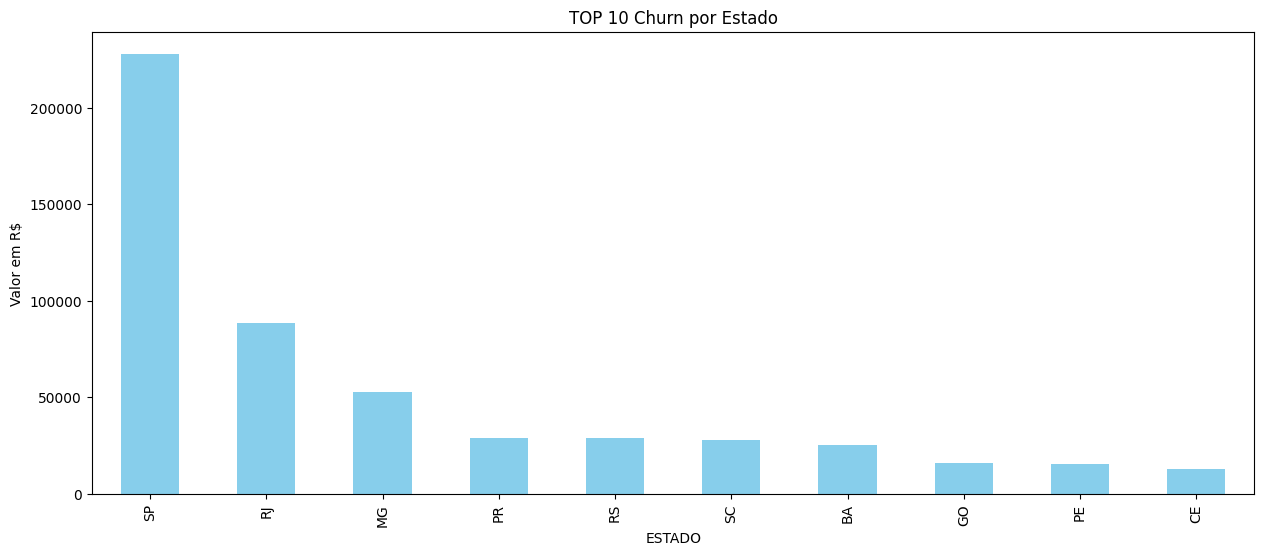

In [137]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(15,6))
prejuizo_por_estado.head(10).plot(kind='bar', color='skyblue')
plt.title('TOP 10 Churn por Estado')
plt.ylabel('Valor em R$')
plt.show()

In [126]:
print(f'Esse é o valor de CHURN do TOP 5 estados: R${prejuizo_por_estado.head(5).sum():.2f}')
print(f'Porcentagem de prejuizo do top 5 Estados: {prejuizo_por_estado.head(5).sum() / financeiro * 100:.2f}%')

Esse é o valor de CHURN do TOP 5 estados: R$427962.63
Porcentagem de prejuizo do top 5 Estados: 72.98%


In [127]:
view_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101683 entries, 0 to 101685
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101683 non-null  object        
 1   STATUS_PEDIDO   101683 non-null  object        
 2   DATA_COMPRA     101683 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101683 non-null  object        
 4   VALOR_PAGO      101683 non-null  float64       
 5   ESTADO          101683 non-null  object        
 6   CIDADE          101683 non-null  object        
 7   CHURN           101683 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(5)
memory usage: 6.3+ MB


In [ ]:
view_final['MES_ANO'] = view_final['DATA_COMPRA'].dt.to_period('M')
view_final['MES_ANO']

In [132]:
prejuizo_por_mes = view_final[view_final['CHURN']==True].groupby('MES_ANO')['VALOR_PAGO'].sum()

print(prejuizo_por_mes)

MES_ANO
2016-09      252.24
2016-10    12523.77
2017-01    10942.37
2017-02    20609.36
2017-03    35494.21
2017-04    26835.85
2017-05    25852.09
2017-06    21050.78
2017-07    25978.99
2017-08    28395.71
2017-09    26592.46
2017-10    28537.61
2017-11    41354.75
2017-12    35202.31
2018-01    36397.32
2018-02    25952.46
2018-03    38974.12
2018-04    27851.53
2018-05    25145.46
2018-06    11789.82
2018-07    38636.89
2018-08    37011.04
2018-09     4439.54
2018-10      589.67
Freq: M, Name: VALOR_PAGO, dtype: float64


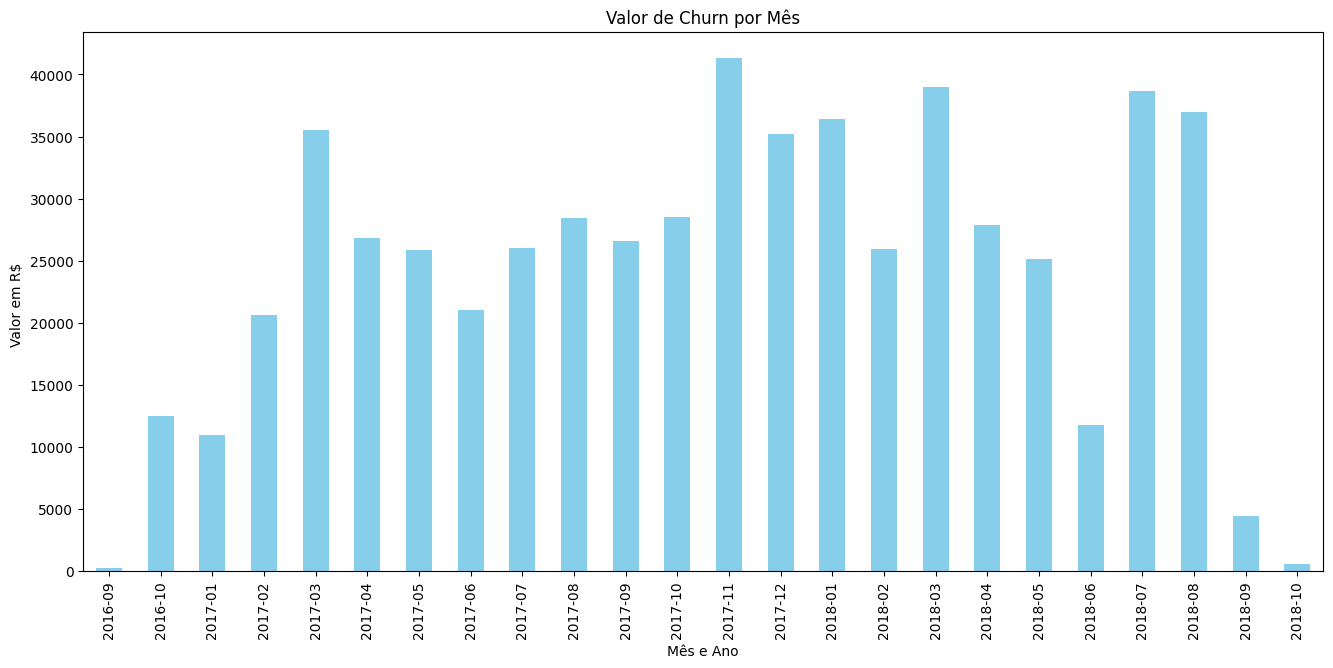

In [140]:
plt.figure(figsize=(16, 7))
prejuizo_por_mes.plot(kind='bar', color='skyblue')
plt.title('Valor de Churn por Mês')
plt.xlabel("Mês e Ano")
plt.ylabel("Valor em R$ ")
plt.show()

In [141]:
view_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101683 entries, 0 to 101685
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101683 non-null  object        
 1   STATUS_PEDIDO   101683 non-null  object        
 2   DATA_COMPRA     101683 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101683 non-null  object        
 4   VALOR_PAGO      101683 non-null  float64       
 5   ESTADO          101683 non-null  object        
 6   CIDADE          101683 non-null  object        
 7   CHURN           101683 non-null  bool          
 8   MES_ANO         101683 non-null  period[M]     
dtypes: bool(1), datetime64[ns](1), float64(1), object(5), period[M](1)
memory usage: 7.1+ MB


In [146]:
# Comparando o valor médio dos pedidos (Churn vs Entrega) no Top 5 Estados
top5_ufs = ['SP', 'RJ', 'MG', 'RS', 'PR']
ticket_comparativo = view_final[view_final['ESTADO'].isin(top5_ufs)].groupby('CHURN')['VALOR_PAGO'].mean()
print("Ticket Médio no Top 5 (Churn vs Entrega):")
print(f'Ticket médio de pedidos entregues: {ticket_comparativo.iloc[0]:.2f}')
print(f'Ticket médio de pedidos com Churn: {ticket_comparativo.iloc[1]:.2f}')

Ticket Médio no Top 5 (Churn vs Entrega):
Ticket médio de pedidos entregues: 148.30
Ticket médio de pedidos com Churn: 184.39


In [148]:
df_final = view_final.drop(columns=['MES_ANO'])

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101683 entries, 0 to 101685
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_PEDIDO       101683 non-null  object        
 1   STATUS_PEDIDO   101683 non-null  object        
 2   DATA_COMPRA     101683 non-null  datetime64[ns]
 3   TIPO_PAGAMENTO  101683 non-null  object        
 4   VALOR_PAGO      101683 non-null  float64       
 5   ESTADO          101683 non-null  object        
 6   CIDADE          101683 non-null  object        
 7   CHURN           101683 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(5)
memory usage: 6.3+ MB


In [151]:
df_final.to_sql('FATO_CHURN', con=engine, if_exists='replace', index=False)

27